In [10]:
import pandas as pd

# Carregando os dados de avaliação da alfabetização por município
caminho = 'C:\\POS FIAP\\FASE 2\\DADOS'
df_municipio = pd.read_csv(caminho + '\\br_inep_avaliacao_alfabetizacao_municipio.csv.gz')

# Carregando os dados de metas de alfabetização por município
df_meta = pd.read_csv(caminho + '\\br_inep_avaliacao_alfabetizacao_meta_alfabetizacao_municipio.csv.gz')

# Verificando as dimensões iniciais das bases
print("Dimensões - Avaliação por Município:", df_municipio.shape)
print("Dimensões - Metas por Município:", df_meta.shape)

# Exibindo as primeiras linhas do dataset de avaliação
display(df_municipio.head())

Dimensões - Avaliação por Município: (23995, 15)
Dimensões - Metas por Município: (10704, 13)


,ano,id_municipio,serie,rede,taxa_alfabetizacao,media_portugues,proporcao_aluno_nivel_0,proporcao_aluno_nivel_1,proporcao_aluno_nivel_2,proporcao_aluno_nivel_3,proporcao_aluno_nivel_4,proporcao_aluno_nivel_5,proporcao_aluno_nivel_6,proporcao_aluno_nivel_7,proporcao_aluno_nivel_8
0,2023,1100031,2,3,69.10,767.8763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,1100072,2,3,58.20,747.8918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,1100189,2,5,69.73,762.4062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023,1101609,2,3,50.70,745.6802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023,1101807,2,3,55.69,752.3724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# --- 1. INSPEÇÃO DO DATASET DE AVALIAÇÃO MUNICIPAL ---
print("================ ECOSSISTEMA: AVALIAÇÃO MUNICIPAL ================")
print(df_municipio.info())
print("\nValores Nulos por Coluna (Município):\n", df_municipio.isnull().sum())
print("\nColunas disponíveis:", df_municipio.columns.tolist())

# --- 2. INSPEÇÃO DO DATASET DE METAS ---
print("\n================ ECOSSISTEMA: METAS MUNICIPAIS ================")
print(df_meta.info())
print("\nValores Nulos por Coluna (Meta):\n", df_meta.isnull().sum())
print("\nColunas disponíveis:", df_meta.columns.tolist())

================ ECOSSISTEMA: AVALIAÇÃO MUNICIPAL ================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23995 entries, 0 to 23994
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ano                      23995 non-null  int64  
 1   id_municipio             23995 non-null  int64  
 2   serie                    23995 non-null  int64  
 3   rede                     23995 non-null  int64  
 4   taxa_alfabetizacao       23995 non-null  float64
 5   media_portugues          23995 non-null  float64
 6   proporcao_aluno_nivel_0  12448 non-null  float64
 7   proporcao_aluno_nivel_1  12448 non-null  float64
 8   proporcao_aluno_nivel_2  12448 non-null  float64
 9   proporcao_aluno_nivel_3  12448 non-null  float64
 10  proporcao_aluno_nivel_4  12448 non-null  float64
 11  proporcao_aluno_nivel_5  12448 non-null  float64
 12  proporcao_aluno_nivel_6  12448 non-null  float64
 13  proporcao

In [8]:
print("================ DIAGNÓSTICO DE CHAVES ================")
print("--- DF_MUNICIPIO (Chaves) ---")
print(df_municipio[['ano', 'id_municipio', 'rede']].dtypes)
print(df_municipio[['ano', 'id_municipio', 'rede']].head(3))

print("\n--- DF_META (Chaves) ---")
print(df_meta[['ano', 'id_municipio', 'rede']].dtypes)
print(df_meta[['ano', 'id_municipio', 'rede']].head(3))

================ DIAGNÓSTICO DE CHAVES ================
--- DF_MUNICIPIO (Chaves) ---
ano              int64
id_municipio     int64
rede            object
dtype: object
    ano  id_municipio rede
0  2023       1100031  NaN
1  2023       1100072  NaN
2  2023       1100189  NaN

--- DF_META (Chaves) ---
ano              int64
id_municipio     int64
rede            object
dtype: object
    ano  id_municipio       rede
0  2023       4301750  Municipal
1  2024       4301750  Municipal
2  2024       2406908  Municipal


In [11]:
# 1. Recarregando a base de municípios para restaurar a coluna 'rede' original (numérica)
df_municipio = pd.read_csv(caminho + '\\br_inep_avaliacao_alfabetizacao_municipio.csv.gz')

# 2. Definindo o dicionário de mapeamento com chaves INTEIRAS (correspondendo ao tipo int64 original)
mapeamento_rede_int = {
    3: 'Municipal',
    2: 'Estadual',
    1: 'Federal',
    4: 'Privada',
    0: 'Total'
}

# 3. Mapeando e criando a coluna descritiva 'rede' padronizada para o merge
df_municipio['rede_desc'] = df_municipio['rede'].map(mapeamento_rede_int)

# Filtrando apenas a rede municipal em ambas as bases
df_mun_municipal = df_municipio[df_municipio['rede_desc'] == 'Municipal'].copy()
df_mun_municipal['rede'] = 'Municipal' # Padronizando o nome da chave para o merge

df_meta_municipal = df_meta[df_meta['rede'] == 'Municipal'].copy()

# 4. Executando o merge definitivo
df_consolidado = pd.merge(
    df_mun_municipal, 
    df_meta_municipal, 
    on=['ano', 'id_municipio', 'rede'], 
    how='inner',
    suffixes=('_real', '_meta')
)

print("Dimensões do DataFrame Consolidado (Municipal):", df_consolidado.shape)
display(df_consolidado.head())

Dimensões do DataFrame Consolidado (Municipal): (10654, 26)


,ano,id_municipio,serie,rede,taxa_alfabetizacao_real,media_portugues,proporcao_aluno_nivel_0,proporcao_aluno_nivel_1,proporcao_aluno_nivel_2,proporcao_aluno_nivel_3,...,taxa_alfabetizacao_meta,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,nivel_alfabetizacao,percentual_participacao
0,2023,1100031,2,Municipal,69.10,767.8763,NaN,NaN,NaN,NaN,...,69.1,70.85,72.53,74.15,75.71,77.21,78.64,80,3.0,90.48
1,2023,1100072,2,Municipal,58.20,747.8918,NaN,NaN,NaN,NaN,...,58.2,61.82,65.31,68.64,71.79,74.74,77.48,80,2.0,92.25
2,2023,1101609,2,Municipal,50.70,745.6802,NaN,NaN,NaN,NaN,...,50.7,55.53,60.25,64.80,69.09,73.07,76.71,80,2.0,95.00
3,2023,1101807,2,Municipal,55.69,752.3724,NaN,NaN,NaN,NaN,...,55.7,59.72,63.63,67.37,70.89,74.18,77.22,80,2.0,83.15
4,2023,1302900,2,Municipal,53.17,731.0744,NaN,NaN,NaN,NaN,...,53.2,57.61,61.93,66.08,69.99,73.62,76.97,80,2.0,78.48


Código para Criar a Variável-Alvo (Target)

### Definição e Lógica da Variável-Alvo (*Target*)

No contexto da nossa análise preditiva para o monitoramento educacional, a criação da variável-alvo (`target_sucesso_meta`) traduz um problema de negócio essencial em políticas públicas: **identificar se um município atingiu ou superou a meta de alfabetização projetada para o horizonte de 2026**.

#### 1. Formulação Matemática
O alvo foi estruturado como uma **classificação binária** baseada na comparação direta entre o desempenho efetivo do município e a meta estipulada:

$target\_sucesso\_meta = (taxa\_alfabetizacao\_real \ge meta\_alfabetizacao\_2026)$

#### 2. Codificação das Classes
* **1 (Sucesso):** Indica que a taxa real de alfabetização alcançada pelo município é maior ou igual à meta planejada para 2026.
* **0 (Risco Educacional):** Indica que o município encontra-se abaixo da meta projetada, sinalizando uma zona de atenção prioritária para intervenções pedagógicas e alocação de recursos.

#### 3. Contexto Analítico (EDA)
A verificação da distribuição das classes revelou um cenário de **desbalanceamento**:
* Cerca de **72,6%** dos registros concentram-se na classe `0` (Risco Educacional).
* Apenas **27,4%** encontram-se na classe `1` (Sucesso).

Esse diagnóstico orientará as próximas etapas da modelagem preditiva, exigindo o uso de métricas adequadas (como F1-Score e ROC-AUC) e o tratamento preventivo da assimetria entre as classes.

In [12]:
# Criando a variável-alvo (Target): 1 se atingiu ou superou a meta de 2026, 0 caso contrário
df_consolidado['target_sucesso_meta'] = (
    df_consolidado['taxa_alfabetizacao_real'] >= df_consolidado['meta_alfabetizacao_2026']
).astype(int)

# Verificando a distribuição das classes na nossa variável-alvo
print("Distribuição da Variável-Alvo (0 = Risco, 1 = Sucesso):")
print(df_consolidado['target_sucesso_meta'].value_counts(normalize=True) * 100)

Distribuição da Variável-Alvo (0 = Risco, 1 = Sucesso):
target_sucesso_meta
0    72.592454
1    27.407546
Name: proportion, dtype: float64


C:\Users\IGOR\AppData\Local\Temp\ipykernel_20992\3086304137.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\IGOR\AppData\Local\Temp\ipykernel_20992\3086304137.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Risco Educacional (0)', 'Sucesso na Meta (1)'])


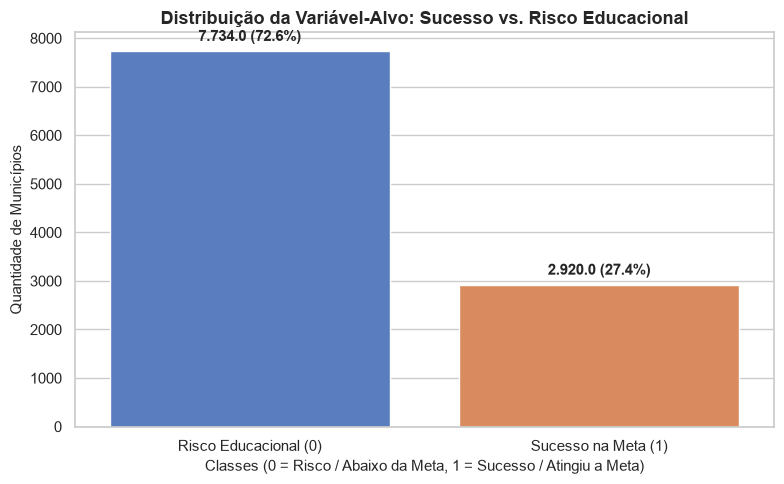

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo visual dos gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Criando o gráfico de contagem para a variável-alvo
ax = sns.countplot(
    x='target_sucesso_meta', 
    data=df_consolidado, 
    palette='muted'
)

plt.title('Distribuição da Variável-Alvo: Sucesso vs. Risco Educacional', fontsize=13, fontweight='bold')
plt.xlabel('Classes (0 = Risco / Abaixo da Meta, 1 = Sucesso / Atingiu a Meta)', fontsize=11)
plt.ylabel('Quantidade de Municípios', fontsize=11)

# Ajustando os ticks do eixo X para melhor legibilidade
ax.set_xticklabels(['Risco Educacional (0)', 'Sucesso na Meta (1)'])

# Calculando as porcentagens para exibir nas barras
total = len(df_consolidado)
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(
        f'{height:,} ({percentage:.1f}%)'.replace(',', '.'),
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

A análise de correlação é um passo fundamental na EDA para identificarmos quais variáveis numéricas possuem forte relação linear com a nossa variável-alvo e entre si, auxiliando na escolha dos atributos (features) para o modelo de Machine Learning.

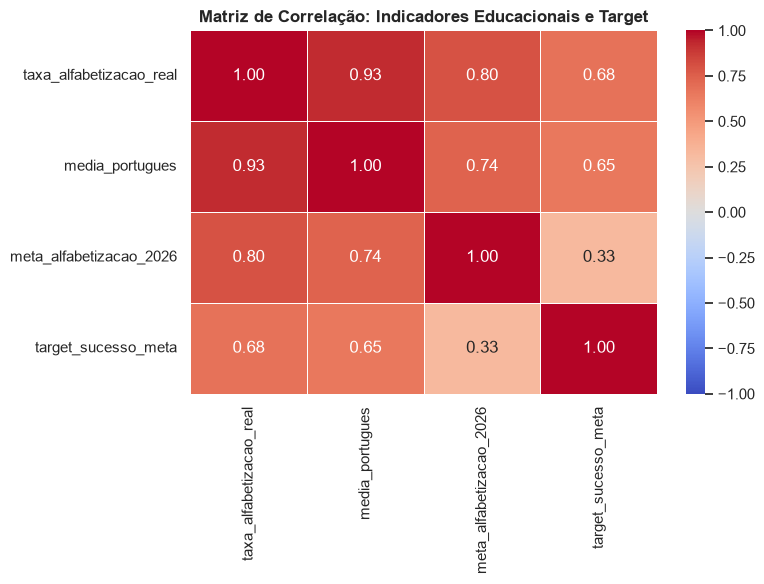

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionando algumas das principais colunas numéricas e o nosso target para a correlação
colunas_numericas = [
    'taxa_alfabetizacao_real', 
    'media_portugues', 
    'meta_alfabetizacao_2026', 
    'target_sucesso_meta'
]

# Calculando a matriz de correlação de Pearson
matriz_corr = df_consolidado[colunas_numericas].corr()

# Configurando o gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_corr, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title('Matriz de Correlação: Indicadores Educacionais e Target', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## A Estratégia de Tratamento de Valores Nulos na Modelagem Preditiva

A etapa de tratamento de valores ausentes (*missing values*) é um dos pilares mais críticos na construção de uma pipeline de Machine Learning robusta. Compreender o momento certo e a motivação técnica para aplicar essa técnica faz toda a diferença na qualidade do modelo preditivo.

---

### 1. O Tratamento de Nulos por Imputação
A grande maioria dos algoritmos de aprendizado de máquina baseados em matrizes numéricas (como os disponíveis no Scikit-learn) não consegue processar valores nulos nativamente, resultando em erros de execução. 
* **Estratégia de Imputação:** Em vez de descartar os registros que possuem alguma lacuna — o que reduziria drasticamente a quantidade de municípios analisados e introduziria viés amostral —, optamos por preencher esses valores utilizando a **mediana**.
* **Vantagem Estatística:** A escolha da mediana em vez da média protege o conjunto de dados contra a distorção causada por valores discrepantes (*outliers*), garantindo uma representatividade mais estável das características educacionais.

### 2. Por que esse tratamento não foi feito no início do projeto?
Durante as primeiras fases de um projeto de Ciência de Dados, realizar o tratamento de nulos de forma precipitada logo na ingestão dos dados pode comprometer boas práticas analíticas por três motivos principais:

* **Preservação do Diagnóstico Exploratório (EDA):** No início, o objetivo é inspecionar e entender a "saúde" dos dados brutos. Saber onde e por que os dados estão faltando (como proporções de níveis de aprendizado não informadas por determinados municípios) é um insight analítico valioso que se perde caso os nulos sejam mascarados antecipadamente.
* **Escopo Direto de Variáveis:** O tratamento de nulos deve ser direcionado exclusivamente ao subconjunto de *features* que efetivamente participará do treinamento do modelo. Como a seleção das variáveis preditoras acontece após a análise de correlação e relevância, aplicar imputações em colunas que seriam descartadas seria um esforço computacional inútil.
* **Prevenção de Vazamento de Dados (*Data Leakage*):** Em uma metodologia rigorosa de Machine Learning, as métricas usadas para preencher os nulos (como a mediana) devem ser extraídas estritamente do conjunto de treinamento, impedindo que informações do conjunto de teste influenciem o aprendizado do modelo. Por essa razão, a imputação ocorre logicamente após a separação dos dados, integrando a preparação final para a modelagem.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import pandas as pd

# 1. Selecionando as features preditivas e o target
features = ['taxa_alfabetizacao_real', 'media_portugues', 'meta_alfabetizacao_2026']
X = df_consolidado[features]
y = df_consolidado['target_sucesso_meta']

# 2. Tratando valores nulos com a mediana das colunas
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=features)

# 3. Dividindo em treino (80%) e teste (20%) com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dimensões do conjunto de Treino: {X_train.shape}")
print(f"Dimensões do conjunto de Teste: {X_test.shape}")

Dimensões do conjunto de Treino: (8523, 3)
Dimensões do conjunto de Teste: (2131, 3)


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Instanciando o modelo de Regressão Logística
modelo = LogisticRegression(random_state=42)

# 2. Treinando o modelo utilizando exclusivamente os dados de treino
modelo.fit(X_train, y_train)

# 3. Realizando previsões no conjunto de teste (dados que o modelo nunca viu)
y_pred = modelo.predict(X_test)

# 4. Avaliando a performance preditiva
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia do Modelo: {acuracia * 100:.2f}%\n")

print("Relatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred))

Acurácia do Modelo: 100.00%

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1547
           1       1.00      1.00      1.00       584

    accuracy                           1.00      2131
   macro avg       1.00      1.00      1.00      2131
weighted avg       1.00      1.00      1.00      2131



In [17]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# 1. Selecionando APENAS features legítimas (sem usar a taxa real ou a meta futura)
features_seguras = [
    'media_portugues', 
    'proporcao_aluno_nivel_0', 
    'proporcao_aluno_nivel_1', 
    'proporcao_aluno_nivel_2', 
    'proporcao_aluno_nivel_3'
]

X = df_consolidado[features_seguras]
y = df_consolidado['target_sucesso_meta']

# 2. Tratando valores nulos (muito comuns nas colunas de níveis de alunos) com a mediana
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=features_seguras)

# 3. Divisão estratificada entre treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Treinando o novo modelo de Regressão Logística
modelo_real = LogisticRegression(random_state=42, max_iter=1000)
modelo_real.fit(X_train, y_train)

# 5. Realizando previsões e avaliando o desempenho real
y_pred = modelo_real.predict(X_test)

acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia Real do Modelo: {acuracia * 100:.2f}%\n")
print("Relatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred))

Acurácia Real do Modelo: 88.27%

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      1547
           1       0.83      0.71      0.77       584

    accuracy                           0.88      2131
   macro avg       0.87      0.83      0.85      2131
weighted avg       0.88      0.88      0.88      2131



In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Instanciando o modelo Random Forest com ajuste de balanceamento e controle de aleatoriedade
modelo_rf = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

# 2. Treinando o modelo com os dados já limpos e divididos (X_train, y_train)
modelo_rf.fit(X_train, y_train)

# 3. Realizando previsões no conjunto de teste
y_pred_rf = modelo_rf.predict(X_test)

# 4. Avaliando os novos resultados
acuracia_rf = accuracy_score(y_test, y_pred_rf)
print(f"Acurácia do Random Forest: {acuracia_rf * 100:.2f}%\n")

print("Relatório de Classificação Detalhado (Random Forest):")
print(classification_report(y_test, y_pred_rf))

Acurácia do Random Forest: 85.88%

Relatório de Classificação Detalhado (Random Forest):
              precision    recall  f1-score   support

           0       0.92      0.88      0.90      1547
           1       0.72      0.80      0.76       584

    accuracy                           0.86      2131
   macro avg       0.82      0.84      0.83      2131
weighted avg       0.87      0.86      0.86      2131

